<a href="https://colab.research.google.com/github/Tatutina/COVID-19_Project/blob/code/%D0%90%D0%BD%D0%B0%D0%BB%D0%B8%D0%B7_%D0%A1OVID_19.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [119]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [120]:
import warnings
warnings.filterwarnings('ignore')

In [121]:
# Установка lifelines для анализа выживаемости
!pip install lifelines

# Дополнительные зависимости для визуализации
!pip install seaborn matplotlib

print("✅ lifelines установлен! Теперь запустите анализ выживаемости.")

✅ lifelines установлен! Теперь запустите анализ выживаемости.


In [122]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, mannwhitneyu, ttest_ind, shapiro
from datetime import datetime
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

In [123]:
df=pd.read_csv('/content/drive/MyDrive/COVID19_Project/data/COVID-19_RECOVERY_DATASET.csv')
df.head()

,patient_id,country,region/state,date_reported,age,gender,comorbidities,symptoms_1,symptoms_2,symptoms_3,...,days_to_recovery,recovered,death,date_of_recovery,date_of_death,tests_conducted,test_type,hospital_name,doctor_assigned,source_url
0,P000001,India,Sindh,44447,95,Female,Diabetes,Cough,NaN,NaN,...,18,0,1,44465.0,NaN,1,PCR,Aga Khan,Dr. Müller,https://who.int/sample
1,P000002,Pakistan,London,43930,92,Female,Diabetes,Loss of Smell,Fatigue,Fatigue,...,9,0,1,43939.0,NaN,3,PCR,Jinnah Hospital,Dr. Silva,https://who.int/sample
2,P000003,Germany,Berlin,44718,78,Female,NaN,Headache,Loss of Smell,Loss of Smell,...,27,0,1,44745.0,NaN,2,Antigen,Jinnah Hospital,Dr. Smith,https://who.int/sample
3,P000004,India,Cape Town,44107,36,Female,Cancer,Cough,Fatigue,Fatigue,...,25,1,1,44132.0,NaN,2,PCR,Mayo Clinic,Dr. Silva,https://who.int/sample
4,P000005,UK,Berlin,44083,99,Male,Diabetes,Fatigue,NaN,NaN,...,17,0,0,NaN,44123.0,4,PCR,AIIMS,Dr. Smith,https://who.int/sample


In [124]:
df.columns

Index(['patient_id', 'country', 'region/state', 'date_reported', 'age',
       'gender', 'comorbidities', 'symptoms_1', 'symptoms_2', 'symptoms_3',
       'severity', 'hospitalized', 'icu_admission', 'ventilator_support',
       'vaccination_status', 'variant', 'treatment_given_1',
       'treatment_given_2', 'days_to_recovery', 'recovered', 'death',
       'date_of_recovery', 'date_of_death', 'tests_conducted', 'test_type',
       'hospital_name', 'doctor_assigned', 'source_url'],
      dtype='object')

In [125]:
# Удаление неинформотивных признаков
columns_to_remove = ["patient_id", 'source_url', 'country', 'region/state',
                     'hospital_name', 'doctor_assigned',]
df = df.drop(columns=columns_to_remove)

In [126]:
df.head().T

,0,1,2,3,4
date_reported,44447,43930,44718,44107,44083
age,95,92,78,36,99
gender,Female,Female,Female,Female,Male
comorbidities,Diabetes,Diabetes,NaN,Cancer,Diabetes
symptoms_1,Cough,Loss of Smell,Headache,Cough,Fatigue
symptoms_2,NaN,Fatigue,Loss of Smell,Fatigue,NaN
symptoms_3,NaN,Fatigue,Loss of Smell,Fatigue,NaN
severity,Moderate,Moderate,Critical,Mild,Mild
hospitalized,0,0,0,1,1
icu_admission,1,1,0,1,1


# Проверка нормальности распределения

In [127]:
numeric_cols = df.select_dtypes(include='number').columns

results = []

for col in numeric_cols:
    # берём столбец без пропусков
    data = df[col].dropna()
    # тест Шапиро–Уилка (важно: n <= 5000)
    stat, p = shapiro(data)
    results.append({
        "Показатель": col,
        "W": round(stat, 3),
        "p_value": round(p, 4),
        "Нормально?": "да" if p > 0.05 else "нет"
    })

shapiro_df = pd.DataFrame(results)
display(shapiro_df)


,Показатель,W,p_value,Нормально?
0,date_reported,0.955,0.0,нет
1,age,0.954,0.0,нет
2,hospitalized,0.622,0.0,нет
3,icu_admission,0.427,0.0,нет
4,ventilator_support,0.227,0.0,нет
5,days_to_recovery,0.951,0.0,нет
6,recovered,0.527,0.0,нет
7,death,0.527,0.0,нет
8,date_of_recovery,0.956,0.0,нет
9,date_of_death,0.956,0.0,нет


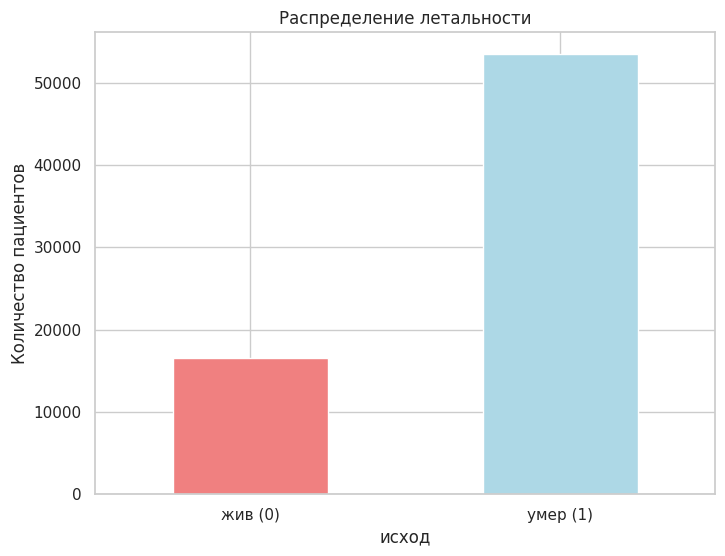

In [128]:
plt.figure(figsize=(8, 6))
ax = df['death'].value_counts().sort_index().plot(kind='bar', color=['lightcoral', 'lightblue'])
plt.title('Распределение летальности')
plt.xlabel('исход')
plt.ylabel('Количество пациентов')
plt.xticks([0, 1], ['жив (0)', 'умер (1)'], rotation=0)

plt.show()

# Сравнительный анализ

## Количественные данные

In [129]:
results_num = []

numeric_cols = df.select_dtypes(include='number').columns
numeric_cols = [c for c in numeric_cols if c != 'death']

for col in numeric_cols:
    grp1 = df.loc[df['death'] == 1, col].dropna()
    grp0 = df.loc[df['death'] == 0, col].dropna()

    # Шапиро–Уилк (ограничение: до 5000 наблюдений) [web:135]
    n1 = min(len(grp1), 5000)
    n0 = min(len(grp0), 5000)
    p_norm1 = shapiro(grp1.sample(n1, random_state=42) if len(grp1) > 5000 else grp1)[1]
    p_norm0 = shapiro(grp0.sample(n0, random_state=42) if len(grp0) > 5000 else grp0)[1]

    normal = (p_norm1 > 0.05) and (p_norm0 > 0.05)

    if normal:
        test_name = 't-test'
        stat, p = ttest_ind(grp1, grp0, equal_var=False)
    else:
        test_name = 'Mann-Whitney'
        stat, p = mannwhitneyu(grp1, grp0, alternative='two-sided')

    results_num.append({
        'Показатель': col,
        'Тест': test_name,
        'p_normal_grp1': round(p_norm1, 4),
        'p_normal_grp0': round(p_norm0, 4),
        'stat': round(stat, 3),
        'p_value': round(p, 4),
        'Есть различия?': 'да' if p < 0.05 else 'нет'
    })

num_stats_df = pd.DataFrame(results_num)
display(num_stats_df.sort_values('p_value'))


,Показатель,Тест,p_normal_grp1,p_normal_grp0,stat,p_value,Есть различия?
1,age,Mann-Whitney,0.0,0.0,356472101.5,0.0000,да
2,hospitalized,Mann-Whitney,0.0,0.0,499663176.0,0.0000,да
3,icu_admission,Mann-Whitney,0.0,0.0,524012952.0,0.0000,да
4,ventilator_support,Mann-Whitney,0.0,0.0,486654640.0,0.0000,да
6,recovered,Mann-Whitney,0.0,0.0,436983272.0,0.0018,да
5,days_to_recovery,Mann-Whitney,0.0,0.0,439536245.5,0.2427,нет
0,date_reported,Mann-Whitney,0.0,0.0,440015138.0,0.3387,нет
9,tests_conducted,Mann-Whitney,0.0,0.0,442445223.0,0.9080,нет
7,date_of_recovery,Mann-Whitney,0.0,NaN,NaN,NaN,нет
8,date_of_death,Mann-Whitney,NaN,0.0,NaN,NaN,нет


## Категориальные данные

In [130]:
from scipy.stats import chi2_contingency

results_cat = []

categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    contingency = pd.crosstab(df[col], df['death'])

    # если в таблице меньше 2 строк или столбцов — пропускаем
    if contingency.shape[0] < 2 or contingency.shape[1] < 2:
        continue

    chi2, p, dof, expected = chi2_contingency(contingency)

    results_cat.append({
        'Показатель': col,
        'chi2': round(chi2, 3),
        'dof': dof,
        'p_value': round(p, 4),
        'Есть связь?': 'да' if p < 0.05 else 'нет'
    })

cat_stats_df = pd.DataFrame(results_cat)
display(cat_stats_df.sort_values('p_value'))

,Показатель,chi2,dof,p_value,Есть связь?
6,vaccination_status,598.733,2,0.0000,да
5,severity,3914.023,3,0.0000,да
3,symptoms_2,16.248,5,0.0062,да
4,symptoms_3,16.074,5,0.0066,да
8,treatment_given_1,5.516,4,0.2384,нет
2,symptoms_1,6.144,5,0.2925,нет
0,gender,0.620,1,0.4312,нет
7,variant,1.606,2,0.4479,нет
10,test_type,0.255,1,0.6132,нет
9,treatment_given_2,1.794,4,0.7736,нет


Распределение событий:
death
1    53456
0    16544
Name: count, dtype: int64

Группы: severity
Mild        41927
Moderate    17558
Severe       6929
Critical     3586
Name: count, dtype: int64


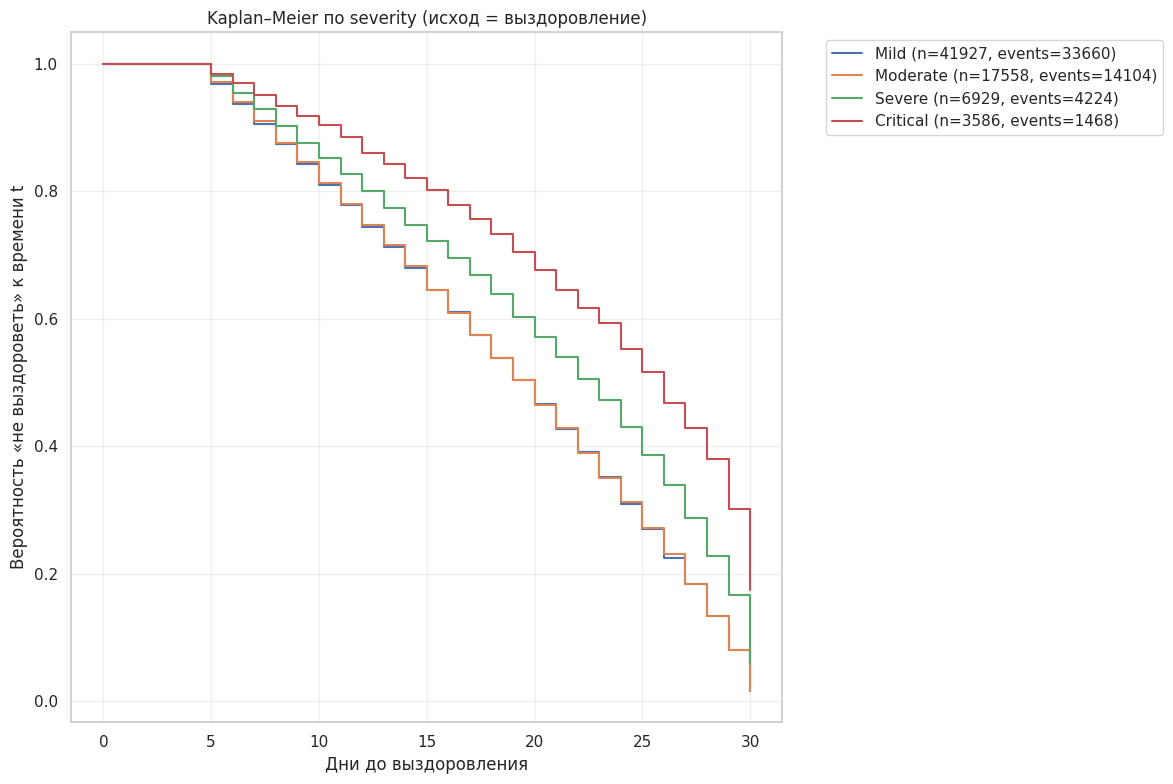

Multivariate log-rank по severity
chi2 = 1096.877 p = 1.7325868555535186e-237

Попарные log-rank тесты:
Mild vs Moderate: p = 0.6956
Mild vs Severe: p = 0.0000
Mild vs Critical: p = 0.0000
Moderate vs Severe: p = 0.0000
Moderate vs Critical: p = 0.0000
Severe vs Critical: p = 0.0000


In [131]:
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test, multivariate_logrank_test
import matplotlib.pyplot as plt
import numpy as np

# 1. Базовая подготовка
time_col = 'days_to_recovery'
event_col = 'death'
group_col = 'severity'          # можно заменить на любую категориальную

df_km = df[[time_col, event_col, group_col]].dropna().copy()
df_km[event_col] = df_km[event_col].astype(int)
df_km[time_col] = df_km[time_col].astype(float)

print("Распределение событий:")
print(df_km[event_col].value_counts())
print("\nГруппы:", df_km[group_col].value_counts())

# 2. Kaplan–Meier по группам
plt.figure(figsize=(12, 8))
kmf = KaplanMeierFitter()

groups = df_km[group_col].value_counts().index  # все уровни фактора
for g in groups:
    mask = df_km[group_col] == g
    T = df_km.loc[mask, time_col]
    E = df_km.loc[mask, event_col]
    if E.sum() == 0:
        # в группе нет выздоровевших, смысла рисовать нет
        continue
    kmf.fit(T, event_observed=E, label=f'{g} (n={len(T)}, events={E.sum()})')
    kmf.plot_survival_function(ci_show=False)

plt.title(f'Kaplan–Meier по {group_col} (исход = выздоровление)')
plt.xlabel('Дни до выздоровления')
plt.ylabel('Вероятность «не выздороветь» к времени t')
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# 3. Log-rank: общий (многогрупповой) тест
result = multivariate_logrank_test(
    event_durations=df_km[time_col],
    groups=df_km[group_col],
    event_observed=df_km[event_col]
)
print("Multivariate log-rank по", group_col)
print("chi2 =", round(result.test_statistic, 3), "p =", float(result.p_value))

# 4. Попарные log-rank (опционально)
print("\nПопарные log-rank тесты:")
for i, g1 in enumerate(groups):
    for g2 in groups[i+1:]:
        mask1 = df_km[group_col] == g1
        mask2 = df_km[group_col] == g2
        res = logrank_test(
            df_km.loc[mask1, time_col],
            df_km.loc[mask2, time_col],
            df_km.loc[mask1, event_col],
            df_km.loc[mask2, event_col],
        )
        print(f"{g1} vs {g2}: p = {float(res.p_value):.4f}")
